In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import seaborn as sns

from joblib import Parallel, delayed

from helper_function import compute_r_nk

sns.set()

### Code for figure 1

For each $\alpha\in (0,1)$ and $\theta\ge 0$, define $v_{n,k}(\alpha, \theta)$ for $1\le k\le n$ as 
$$
v_{n,k}(\alpha, \theta) = \frac{\prod_{i=1}^{k-1}(\theta + i\alpha)}{\prod_{i=1}^{n-1}(\theta + i)} = \alpha^{k-1} \frac{\Gamma(k+\frac{\theta}{\alpha})}{\Gamma(1+\frac{\theta}{\alpha})} \frac{\Gamma(1+\theta)}{\Gamma(n+\theta)}
$$
and define $v_{n,k}(\alpha)$ as
$$
v_{n,k}(\alpha) = \int d\mu(\theta) v_{n,k}(\alpha, \theta)
$$
where $\mu$ is a probability distribution over $[0, +\infty)$. 

Let us define the stochastic process $k_n$ with $k_1=1$ such that 
$$
k_{n+1}|k_{n} = k_n + \text{Bernoulli}(p_{n, k_n}), \quad p_{n, k_n} = \frac{v_{n+1, k_n+1}(\alpha)}{v_{n, k_n}(\alpha)}
$$

To efficiently compute $p_{n,k}$, let us write 
\begin{align*}
 p_{n, k_n} = \frac{v_{n+1, k_n+1}(\alpha)}{v_{n, k_n}(\alpha)} &= \frac{ \int d\mu(\theta) v_{n,k}(\alpha, \theta) \frac{\theta+k\alpha}{\theta+n}}{ \int d\mu(\theta) v_{n,k}(\alpha, \theta)}\\
 &= \frac{k \alpha}{n} \cdot \frac{\int d\mu(\theta) \frac{v_{n,k}(\alpha, \theta)}{v_{n,k}(\alpha,\theta=0)} \frac{\theta+k\alpha}{k\alpha} \frac{n}{\theta+n}}{ \int d\mu(\theta) \frac{v_{n,k}(\alpha, \theta)}{v_{n,k}(\alpha,\theta=0)}}\\
 &= \frac{k \alpha}{n} \cdot \frac{\int d\mu(\theta) r_{n,k}(\alpha,\theta) \frac{1+\theta/(k\alpha)}{1+\theta/n}}{\int d\mu(\theta) r_{n,k}(\alpha, \theta)}
\end{align*}

\begin{align*}
r_{n,k}(\alpha,\theta) &= \frac{v_{n,k}(\alpha, \theta)}{v_{n,k}(\alpha,\theta=0)} \\
&=\alpha^{k-1} \frac{\Gamma(k+\frac{\theta}{\alpha})}{\Gamma(1+\frac{\theta}{\alpha})} \frac{\Gamma(1+\theta)}{\Gamma(n+\theta)} \biggl(\alpha^{k-1} \frac{\Gamma(k)}{\Gamma(n)}\biggr)^{-1}\\
&= \frac{\Gamma(k+\frac{\theta}{\alpha})}{\Gamma(k)} \cdot \frac{\Gamma(n)}{\Gamma(n+\theta)} \cdot \frac{\Gamma(1+\theta)}{\Gamma(1 + \frac{\theta}{\alpha})}\\
&= \exp\Bigl(\phi(k+\theta/\alpha) - \phi(k) + \phi(n)-\phi(n+\theta) + \phi(1+\theta)-\phi(1+\frac{\theta}{\alpha})\Bigr)
\end{align*}
where $\phi(x)=\log \Gamma(x)$


In [2]:
def compute_p_nk_atoms(n, k, alpha, thetas, weights):
    thetas = np.asarray(thetas, float)
    weights = np.asarray(weights, float)
    rs = compute_r_nk(n, k, alpha, thetas)
    denom = sum(rs*weights)
    integrand = (1+thetas/k/alpha)/(1+thetas/n)
    num = sum(rs * integrand * weights)
    return  k * alpha/n * num/denom

def run(alpha, N, seed, thetas, weights):
    rng = np.random.default_rng(seed)
    k=1
    for n in range(1, N):
        prob = compute_p_nk_atoms(n=n, k=k, alpha=alpha, thetas=thetas, weights=weights)
        k += rng.binomial(n=1, p=prob, size=1)[0]
    
    return {
        'K':k,
        'normalized_K':k/N**alpha,
        'inverse_K': N * k**(-1/alpha),
        'alpha': alpha,
        'thetas':thetas,
        'weights':weights,
        'seed': seed
    }

def compute_p_nk_mc(n, k, alpha, sampler, M=2000, seed=0):
    rng = np.random.default_rng(seed)
    thetas = sampler(rng, M)
    # thetas = np.random.uniform(0, 5, size=M)
    rs = compute_r_nk(n=n, k=k, alpha=alpha, theta=thetas)
    denom = np.mean(rs)
    integrand = (1+thetas/k/alpha)/(1+thetas/n)
    num = np.mean(rs * integrand)
    return k * alpha/n * num/denom

def run_mc(alpha, N, seed, sampler):
    rng = np.random.default_rng(seed)
    k=1
    for n in range(1, N):
        prob = compute_p_nk_mc(n=n, k=k, alpha=alpha, sampler=sampler)
        k += rng.binomial(n=1, p=prob, size=1)[0]
    
    return {
        'K':k,
        'normalized_K':k/N**alpha,
        'inverse_K': N * k**(-1/alpha),
        'alpha': alpha,
        'seed': seed
    }

def sampler_uniform(a, b):
    def _s(rng, M):
        return rng.uniform(a, b, size=M)
    return _s

def sampler_harf_gauss(scale=1):
    def _s(rng, M):
        return scale*np.abs(rng.normal(size=M))
    return _s

        

In [ ]:
N = 50000
alpha = 0.3
seeds = range(0, 10000)

# N = 5000
# alpha = 0.3
# seeds = range(0, 1000)

Dirac measures $\delta_0, \delta_3, \delta_{10}$ and the point mass mixture $3^{-1}(\delta_0+\delta_3+\delta_{10})$

In [4]:

thetas_list = [[0], [3], [10], [0, 3, 10]]
weights_list = [[1]*len(thetas) for thetas in thetas_list]
params = [{'alpha':alpha, 'N':N, 'seed':seed, 'thetas':thetas, 'weights':weights}
          for seed in seeds
          for thetas, weights in zip(thetas_list, weights_list)
          ]

print(len(params))

data = Parallel(n_jobs=20, verbose=12)(
        delayed(run)(**d) for d in params)

df_atom = pd.DataFrame(data)


4000


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:  

Uniform[0,10]

In [5]:
sampler = sampler_uniform(0, 10)
params = [{'alpha':alpha, 'N':N, 'seed':seed, 'sampler':sampler}
          for seed in seeds
          ]

print(len(params))

data = Parallel(n_jobs=20, verbose=12)(
        delayed(run_mc)(**d) for d in params)

df_uniform = pd.DataFrame(data)



[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.


1000


[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done  16 tasks      | elapsed:    1.0s
[Paralle

Halfnorm $|N(0,3)|$

In [6]:

sampler = sampler_harf_gauss(scale=3)
params = [{'alpha':alpha, 'N':N, 'seed':seed, 'sampler':sampler}
          for seed in seeds
          ]

print(len(params))

data = Parallel(n_jobs=20, verbose=12)(
        delayed(run_mc)(**d) for d in params)

df_gauss = pd.DataFrame(data)


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.


1000


[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  16 tasks      | elapsed:    1.0s
[Paralle

In [7]:
df_atom.to_csv(f"data/diversity/atom_seed_{len(seeds)}_N_{N}_alpha_{alpha}.csv", index=False)
df_uniform.to_csv(f"data/diversity/uniform_seed_{len(seeds)}_N_{N}_alpha_{alpha}.csv", index=False)
df_gauss.to_csv(f"data/diversity/gauss_seed_{len(seeds)}_N_{N}_alpha_{alpha}.csv", index=False)

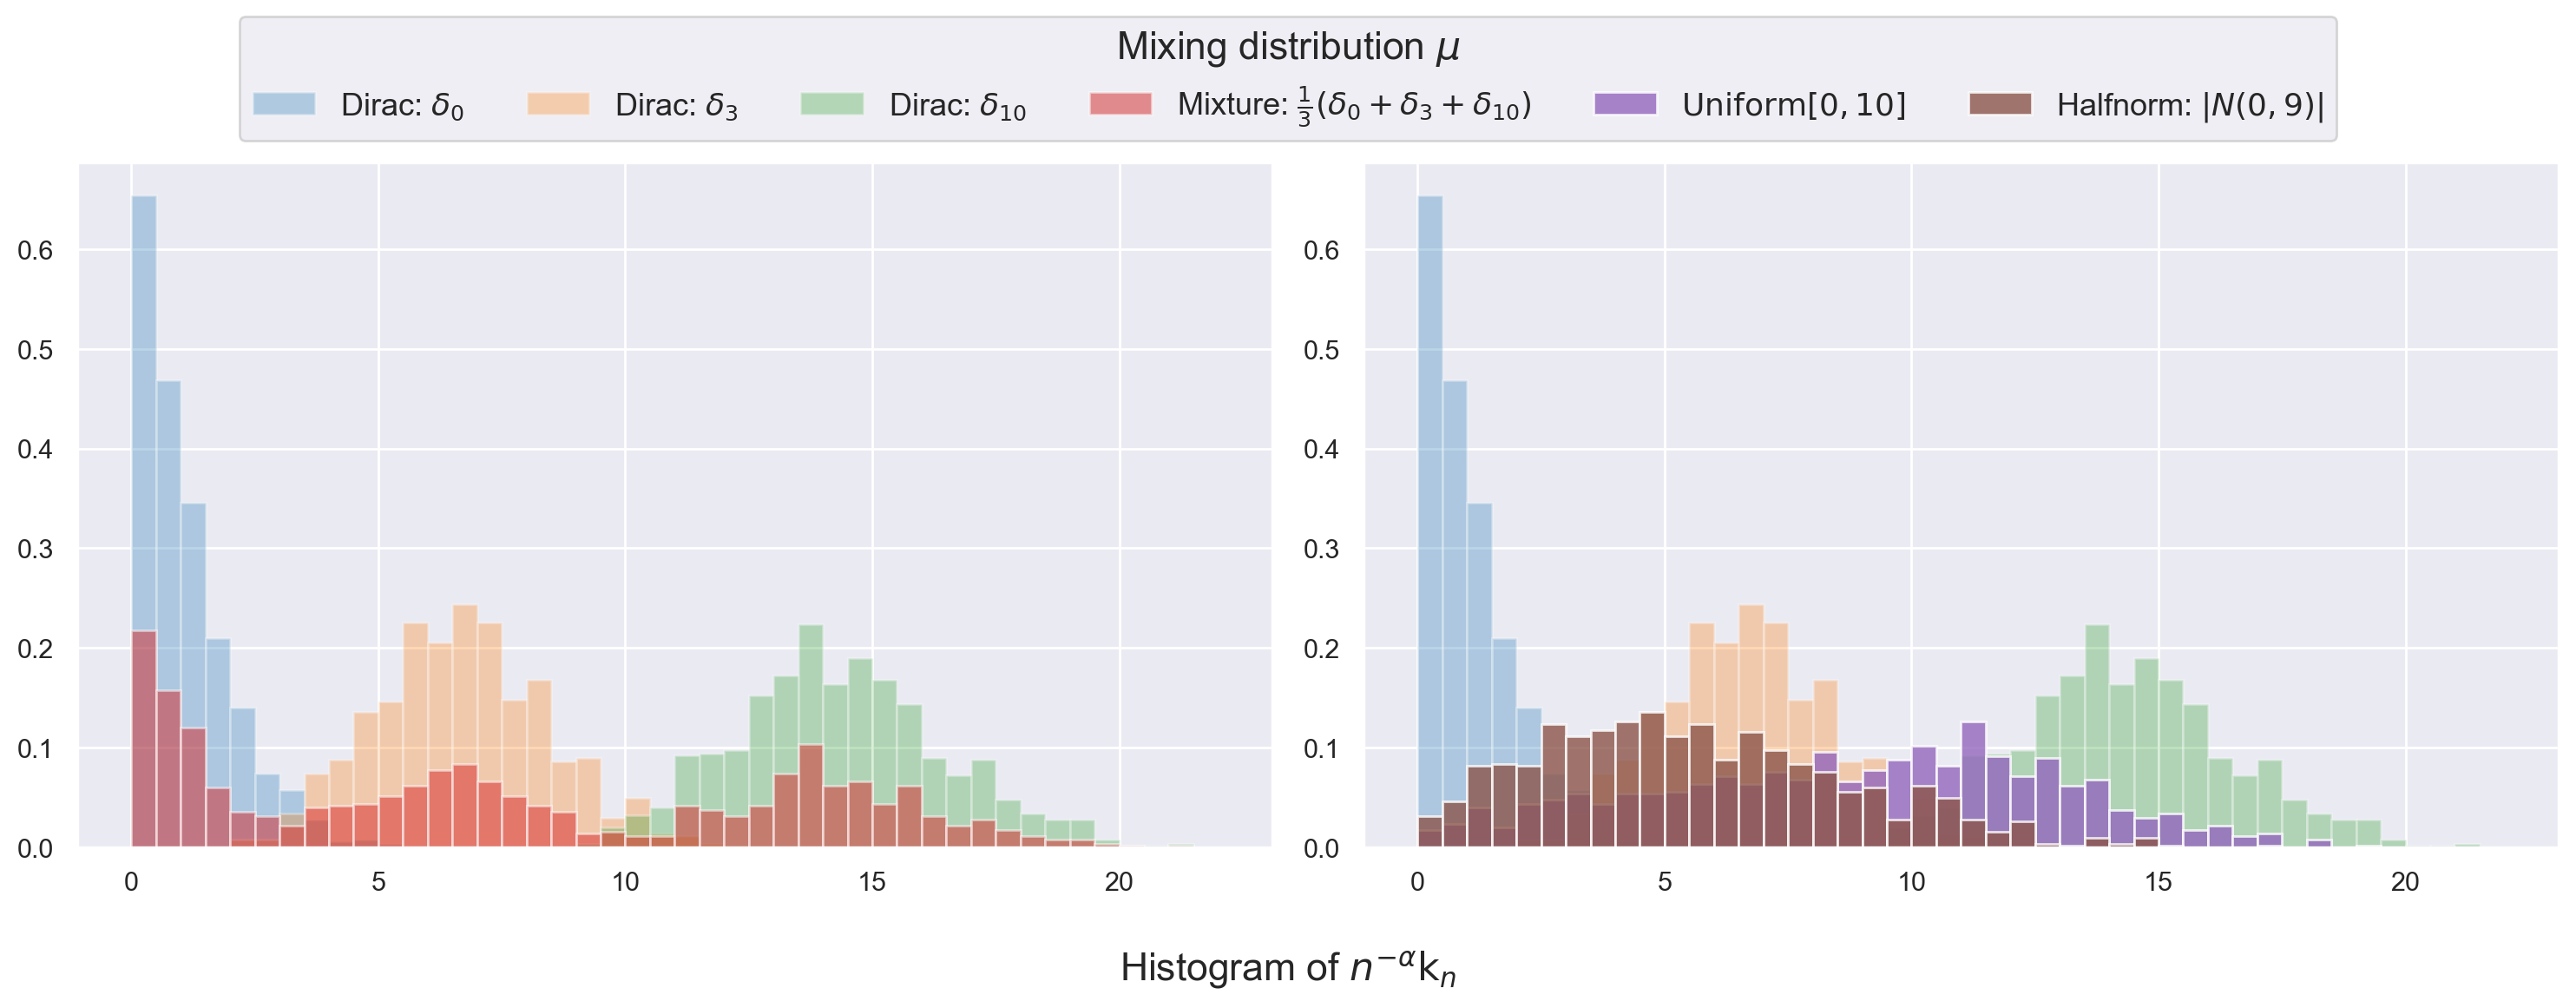

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=200)

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
]

labels = [
    r"Dirac: $\delta_0$",
    r"Dirac: $\delta_3$",
    r"Dirac: $\delta_{10}$",
    r"Mixture: $\frac{1}{3}(\delta_0 + \delta_3 + \delta_{10})$",
    r"$\text{Uniform}[0,10]$",
    r"Halfnorm: $|N(0,9)|$",
]

alp = 0.3
bins = np.linspace(0, 22, 45)

for i, thetas in enumerate(thetas_list[:3]):
    df_filtered = df_atom[df_atom["thetas"].apply(lambda x: x == thetas)]
    for j in [0, 1]:
        axes[j].hist(
            df_filtered["normalized_K"],
            density=True,
            bins=bins,
            label=labels[i],
            alpha=alp,
            color=colors[i],
        )

alp = 0.5

axes[0].hist(
    df_atom[df_atom["thetas"].apply(lambda x: x == thetas_list[3])]["normalized_K"],
    density=True,
    bins=bins,
    label=labels[3],
    alpha=alp,
    color=colors[3],
)

alp = 0.8
axes[1].hist(
    df_uniform["normalized_K"],
    density=True,
    bins=bins,
    label=labels[4],
    alpha=alp,
    color=colors[4],
)

axes[1].hist(
    df_gauss["normalized_K"],
    density=True,
    bins=bins,
    label=labels[5],
    alpha=alp,
    color=colors[5],
)

for ax in axes:
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.grid(True)

# collect from both axes
handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()

all_handles = handles0 + handles1
all_labels = labels0 + labels1

# deduplicate while preserving order
unique = {}
for h, l in zip(all_handles, all_labels):
    if l not in unique:
        unique[l] = h

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    ncol=6,
    bbox_to_anchor=(0.5, 1.15),
    frameon=True,
    fontsize=13,
    title=r"Mixing distribution $\mu$",
    title_fontsize=16,
)

fig.supxlabel(r'Histogram of $n^{-\alpha} \mathsf{k}_n$', fontsize=16)
plt.tight_layout()

filename = f"fig/diversity_atom_seed_{len(seeds)}_N_{N}_alpha_{alpha}_summary.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()